## 05-EDA Visualization

In [1]:
import os

from pyspark.sql import SparkSession
from pyspark.sql.functions import *


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
spark = (
    SparkSession.builder
    .appName("Bus_Risk_EDA")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")


In [4]:
project_path = r"D:\BigDataCoursework"

processed_path = os.path.join(project_path, "Data", "processed", "integrated_journeys.parquet")
journeys_df = spark.read.parquet(processed_path)

journeys_df.show(5)
journeys_df.printSchema()

+----------+-----------+-------------+--------------------+--------------+---------+----------------+---------------+------------------+------------+----------------+--------------+----------------+-----------------+
|Journey_ID|Operator_ID| Service_Code|           Line_Name|Departure_Hour|Peak_Hour|Route_Complexity|Number_of_Stops|        Risk_Score|Service_Risk|Disruption_Count|Has_Disruption|Position_Reports|Has_Live_Tracking|
+----------+-----------+-------------+--------------------+--------------+---------+----------------+---------------+------------------+------------+----------------+--------------+----------------+-----------------+
|      VJ14|       PERY| PB1082425:30|PERY:PB1082425:30...|            18|        1|             315|             54|             46.53|           1|               0|             0|              10|                1|
|      VJ_9|       UNTM|  PK2008218:1|UNTM:PK2008218:1:HB1|             9|        1|             103|              5|            18.

In [5]:
journeys_df.groupBy("Has_Disruption").agg(avg("Risk_Score").alias("Avg_Risk_Score")).show()

+--------------+------------------+
|Has_Disruption|    Avg_Risk_Score|
+--------------+------------------+
|             1|46.026351264770106|
|             0| 80.86966859934714|
+--------------+------------------+



In [6]:
spark.catalog.clearCache()

In [7]:
journeys_df.printSchema()

root
 |-- Journey_ID: string (nullable = true)
 |-- Operator_ID: string (nullable = true)
 |-- Service_Code: string (nullable = true)
 |-- Line_Name: string (nullable = true)
 |-- Departure_Hour: integer (nullable = true)
 |-- Peak_Hour: integer (nullable = true)
 |-- Route_Complexity: long (nullable = true)
 |-- Number_of_Stops: long (nullable = true)
 |-- Risk_Score: double (nullable = true)
 |-- Service_Risk: integer (nullable = true)
 |-- Disruption_Count: long (nullable = true)
 |-- Has_Disruption: integer (nullable = true)
 |-- Position_Reports: long (nullable = true)
 |-- Has_Live_Tracking: integer (nullable = true)



In [8]:
stats_df = journeys_df.select(

    mean("Route_Complexity").alias("Mean_Route_Complexity"),

    expr(
        "percentile_approx(Route_Complexity,0.5)"
    ).alias("Median"),
    
    stddev("Route_Complexity").alias("Std_Dev"),

    skewness("Route_Complexity").alias("Skewness"),

    kurtosis("Route_Complexity").alias("Kurtosis")

)

stats_df.show()

+---------------------+------+------------------+-----------------+-------------------+
|Mean_Route_Complexity|Median|           Std_Dev|         Skewness|           Kurtosis|
+---------------------+------+------------------+-----------------+-------------------+
|    2242.532082287124|   658|2989.9683448978594|1.182879380682848|-0.5736347616535595|
+---------------------+------+------------------+-----------------+-------------------+



In [9]:
risk_distribution = (
    journeys_df
    .groupBy("Service_Risk")
    .count()
    .orderBy("Service_Risk")
)


risk_distribution.show()

+------------+------+
|Service_Risk| count|
+------------+------+
|           0| 54242|
|           1|101722|
|           2| 71046|
+------------+------+



In [10]:
print("Total Records:")
print(journeys_df.count())

print("Columns:")
print(len(journeys_df.columns))

Total Records:
227010
Columns:
14


In [11]:
journeys_df.select(

    [
        count(
            when(col(c).isNull(), c)
        ).alias(c)

        for c in journeys_df.columns
    ]

).show()

+----------+-----------+------------+---------+--------------+---------+----------------+---------------+----------+------------+----------------+--------------+----------------+-----------------+
|Journey_ID|Operator_ID|Service_Code|Line_Name|Departure_Hour|Peak_Hour|Route_Complexity|Number_of_Stops|Risk_Score|Service_Risk|Disruption_Count|Has_Disruption|Position_Reports|Has_Live_Tracking|
+----------+-----------+------------+---------+--------------+---------+----------------+---------------+----------+------------+----------------+--------------+----------------+-----------------+
|         0|          0|           0|        0|             0|        0|               0|              0|         0|           0|               0|             0|               0|                0|
+----------+-----------+------------+---------+--------------+---------+----------------+---------------+----------+------------+----------------+--------------+----------------+-----------------+



In [12]:
risk_df = risk_distribution.toPandas()

In [13]:
results_path = r"D:\BigDataCoursework\Results\charts"


os.makedirs(
    results_path,
    exist_ok=True
)

In [14]:


eda_df = journeys_df.toPandas()

print(eda_df.shape)

eda_df.head()

(227010, 14)


,Journey_ID,Operator_ID,Service_Code,Line_Name,Departure_Hour,Peak_Hour,Route_Complexity,Number_of_Stops,Risk_Score,Service_Risk,Disruption_Count,Has_Disruption,Position_Reports,Has_Live_Tracking
0,VJ14,PERY,PB1082425:30,PERY:PB1082425:30:464,18,1,315,54,46.530,1,0,0,10,1
1,VJ_9,UNTM,PK2008218:1,UNTM:PK2008218:1:HB1,9,1,103,5,18.956,0,0,0,0,0
2,VJ_8,LAKC,PD1020869:7,LAKC:PD1020869:7:205,10,0,174,44,30.248,0,0,0,8,1
3,VJ1,SLEA,PF0007062:2,SLEA:PF0007062:2:Y019,7,1,131,62,53.712,1,0,0,19,1
4,VJ1,PCCO,PF0002252:132,PCCO:PF0002252:132:961,7,1,438,93,72.926,2,0,0,34,1


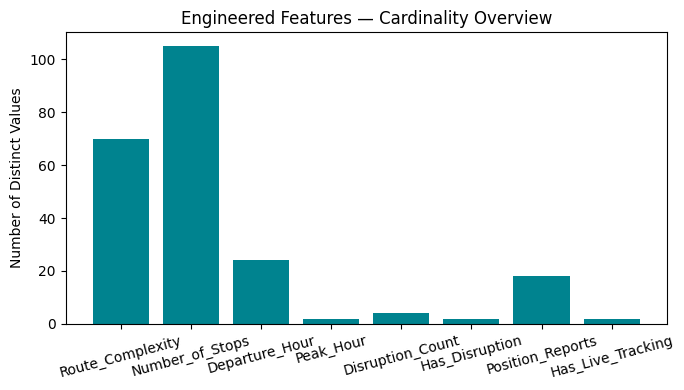

In [15]:
engineered_features = [
    "Route_Complexity", "Number_of_Stops", "Departure_Hour", "Peak_Hour",
    "Disruption_Count", "Has_Disruption", "Position_Reports", "Has_Live_Tracking",
]
distinct_counts = eda_df[engineered_features].nunique()

plt.figure(figsize=(7,4))
plt.bar(distinct_counts.index, distinct_counts.values, color="#00838F")
plt.ylabel("Number of Distinct Values")
plt.title("Engineered Features — Cardinality Overview")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(results_path + "/feature_cardinality.png", dpi=300, bbox_inches="tight")
plt.show()

## Service Risk Distribution

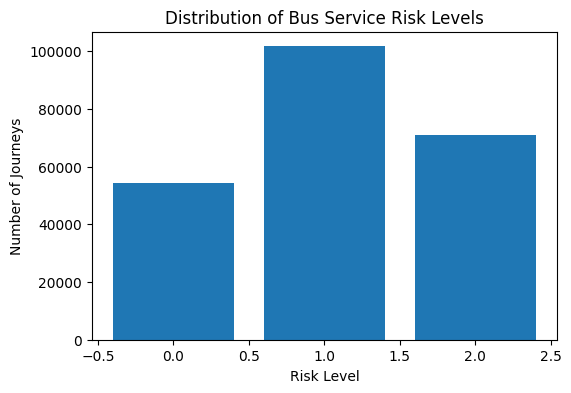

In [16]:
plt.figure(figsize=(6,4))


plt.bar(
    risk_df["Service_Risk"],
    risk_df["count"]
)


plt.title(
    "Distribution of Bus Service Risk Levels"
)

plt.xlabel(
    "Risk Level"
)

plt.ylabel(
    "Number of Journeys"
)


plt.savefig(
    os.path.join(
        results_path,
        "service_risk_distribution.png"
    )
)


plt.show()

plt.close()

## Route Complexity Distribution

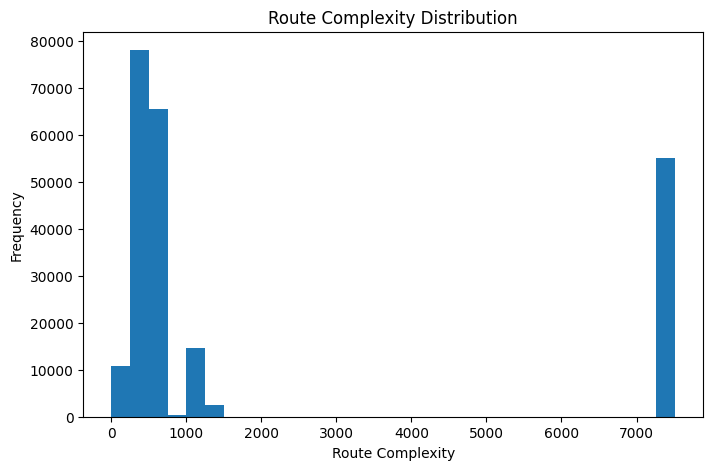

In [17]:
route_df = (
    journeys_df
    .select("Route_Complexity")
    .toPandas()
)


plt.figure(figsize=(8,5))


plt.hist(
    route_df["Route_Complexity"],
    bins=30
)


plt.title(
    "Route Complexity Distribution"
)


plt.xlabel(
    "Route Complexity"
)

plt.ylabel(
    "Frequency"
)


plt.savefig(
    os.path.join(
        results_path,
        "route_complexity_distribution.png"
    )
)


plt.show()

plt.close()

## Outlier Detection

In [18]:
q1,q3 = journeys_df.approxQuantile(
    "Route_Complexity",
    [0.25,0.75],
    0.01
)


iqr = q3-q1


lower = q1 - 1.5*iqr

upper = q3 + 1.5*iqr


print("Lower Bound:",lower)

print("Upper Bound:",upper)



outliers = journeys_df.filter(

    (col("Route_Complexity") < lower) |

    (col("Route_Complexity") > upper)

)


print(
    "Outliers:",
    outliers.count()
)

Lower Bound: -457.5
Upper Bound: 1970.5
Outliers: 55062


## Peak Hour vs Risk

In [19]:
peak_df = (

    journeys_df
    .groupBy(
        "Peak_Hour"
    )
    .count()
    .orderBy(
        "Peak_Hour"
    )

)


peak_df.show()

+---------+------+
|Peak_Hour| count|
+---------+------+
|        0|121362|
|        1|105648|
+---------+------+



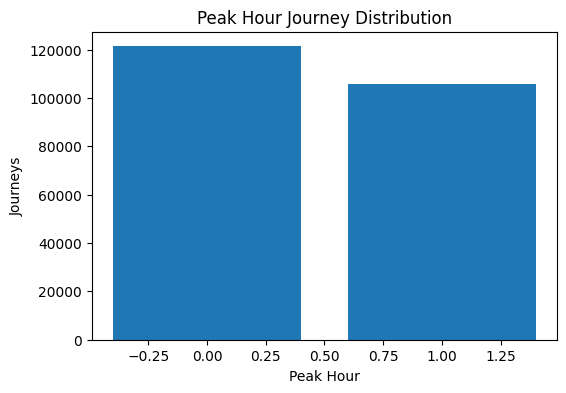

In [20]:
peak_pd = peak_df.toPandas()


plt.figure(figsize=(6,4))


plt.bar(
    peak_pd["Peak_Hour"],
    peak_pd["count"]
)


plt.title(
    "Peak Hour Journey Distribution"
)


plt.xlabel(
    "Peak Hour"
)


plt.ylabel(
    "Journeys"
)


plt.savefig(
    os.path.join(
        results_path,
        "peak_hour_distribution.png"
    )
)


plt.show()

plt.close()

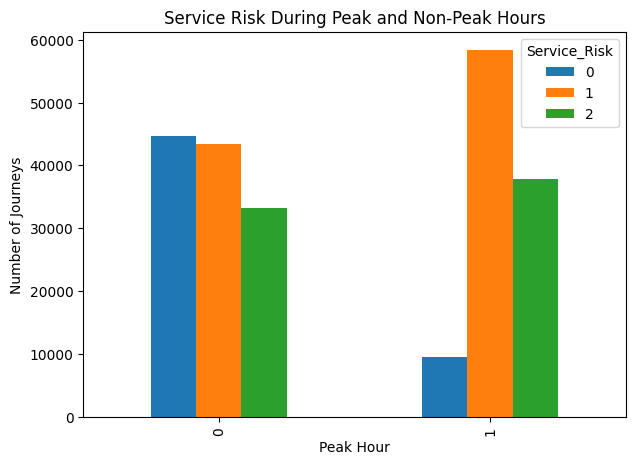

In [21]:
risk_peak = (
    journeys_df
    .groupBy("Peak_Hour", "Service_Risk")
    .count()
    .toPandas()
)

pivot = risk_peak.pivot(
    index="Peak_Hour",
    columns="Service_Risk",
    values="count"
)

pivot.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Service Risk During Peak and Non-Peak Hours")

plt.xlabel("Peak Hour")

plt.ylabel("Number of Journeys")

plt.savefig(
    os.path.join(
        results_path,
        "peak_vs_risk.png"
    )
)

plt.show()

plt.close()

## Top 10 Operators with Highest Risk

In [22]:
operator_df = (

    journeys_df
    .groupBy("Operator_ID")
    .agg(
        sum("Service_Risk")
        .alias("Total_Risk")
    )
    .orderBy(
        desc("Total_Risk")
    )
    .limit(10)

)


operator_df.show()

+-----------+----------+
|Operator_ID|Total_Risk|
+-----------+----------+
|       TANV|    131565|
|    Unknown|     46075|
|       TCNT|     21873|
|       PERY|     12877|
|       PCCO|     10661|
|       BRYL|      5837|
|       COMM|      4597|
|       CELT|      2915|
|       SLEA|      2040|
|       LAKC|      1972|
+-----------+----------+



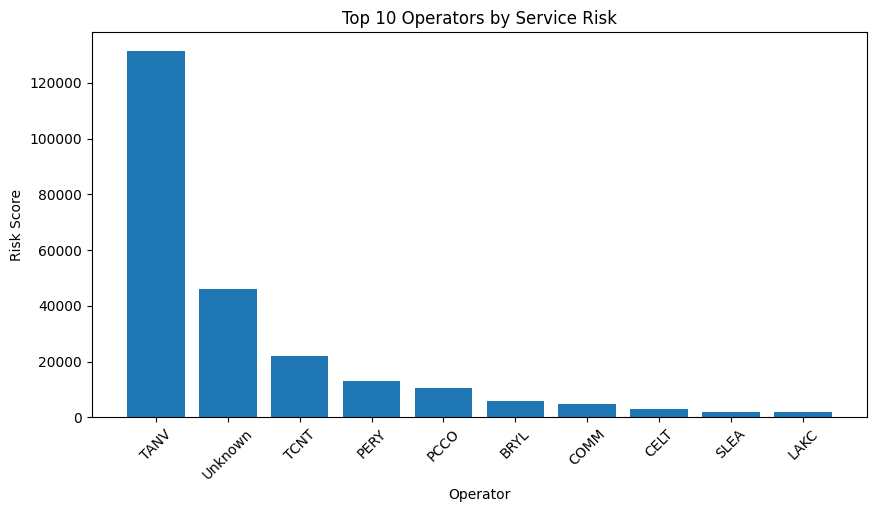

In [23]:
operator_pd = operator_df.toPandas()


plt.figure(figsize=(10,5))


plt.bar(
    operator_pd["Operator_ID"],
    operator_pd["Total_Risk"]
)


plt.xticks(rotation=45)


plt.title(
    "Top 10 Operators by Service Risk"
)


plt.xlabel(
    "Operator"
)


plt.ylabel(
    "Risk Score"
)


plt.savefig(
    os.path.join(
        results_path,
        "operator_risk.png"
    )
)


plt.show()

plt.close()

## Complexity vs Risk

In [24]:
correlation = journeys_df.stat.corr(
    "Route_Complexity",
    "Service_Risk"
)


print(
    "Correlation:",
    correlation
)

Correlation: -0.16778756668876618


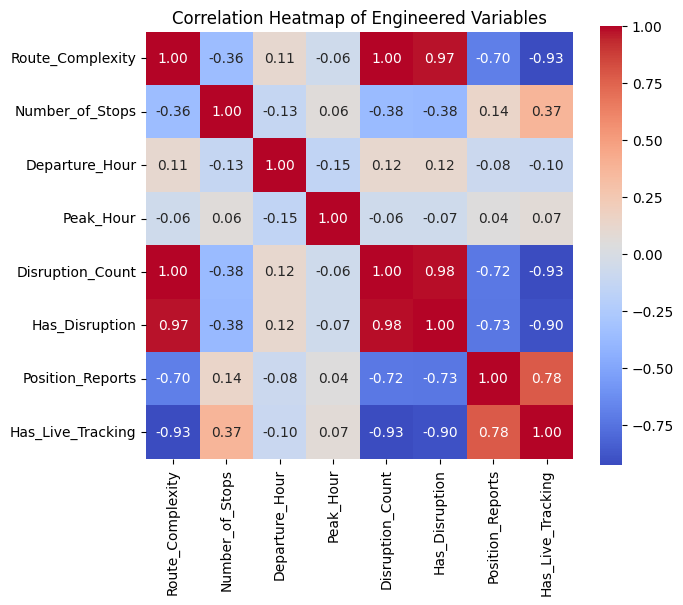

In [26]:
import seaborn as sns

corr_cols = [
    "Route_Complexity", "Number_of_Stops", "Departure_Hour", "Peak_Hour",
    "Disruption_Count", "Has_Disruption", "Position_Reports", "Has_Live_Tracking",
]
corr_matrix = eda_df[corr_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap of Engineered Variables")
plt.tight_layout()
plt.savefig(results_path + "/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

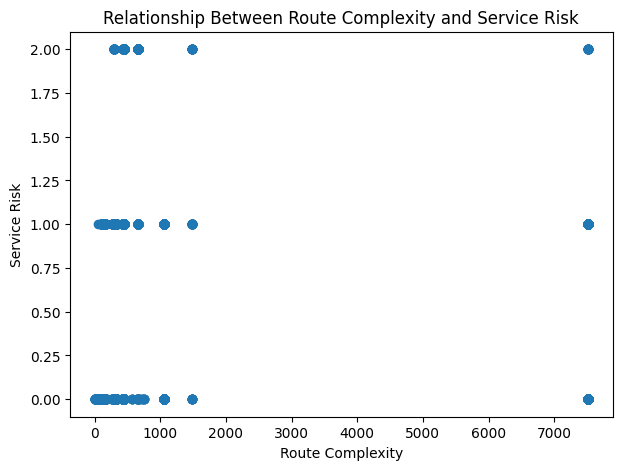

In [27]:
sample_df = (
    journeys_df
    .sample(False, 0.1, 42)
    .limit(5000)
    .select(
        "Route_Complexity",
        "Service_Risk"
    )
    .toPandas()
)



plt.figure(figsize=(7,5))


plt.scatter(
    sample_df["Route_Complexity"],
    sample_df["Service_Risk"]
)


plt.title(
    "Relationship Between Route Complexity and Service Risk"
)


plt.xlabel(
    "Route Complexity"
)


plt.ylabel(
    "Service Risk"
)


plt.savefig(
    os.path.join(
        results_path,
        "complexity_vs_risk.png"
    )
)


plt.show()

plt.close()

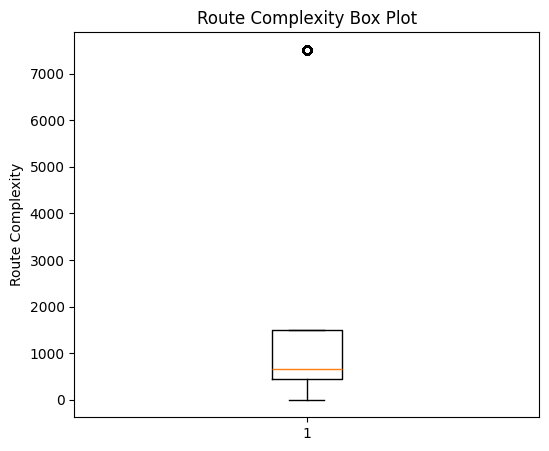

In [28]:
plt.figure(figsize=(6,5))

plt.boxplot(route_df["Route_Complexity"])

plt.title("Route Complexity Box Plot")

plt.ylabel("Route Complexity")

plt.savefig(
    os.path.join(
        results_path,
        "route_complexity_boxplot.png"
    )
)

plt.show()

plt.close()

In [29]:
eda_output = r"D:\BigDataCoursework\Data\processed\eda_dataset"

journeys_df.write.mode("overwrite").parquet(eda_output)

print("EDA dataset saved.")

EDA dataset saved.


In [30]:
print("="*50)
print("EDA Completed Successfully")
print("All Charts Saved")
print(results_path)
print("="*50)

EDA Completed Successfully
All Charts Saved
D:\BigDataCoursework\Results\charts


In [31]:
stats_output = r"D:\BigDataCoursework\Data\processed\eda_statistics"

stats_df.write.mode("overwrite").parquet(stats_output)

print("Statistics saved.")

Statistics saved.
